*Section 1 Data Preparation*

In [15]:
# Cell 1: Imports and Loading
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

base_dir = r"C:\Users\mthar\Documents\Materi Kuliah - Copy\IPB\Semester 6\Visual Komputer Cerdas\katakanamodel3"

# Load the dataset
print("Loading .npz dataset...")
data = np.load(os.path.join(base_dir, 'etl1_katakana.npz'))
x_data = data['images']
y_data = data['labels']

# Load class mapping
with open(os.path.join(base_dir, 'etl1_class_mapping.json'), 'r') as f:
    idx_to_romaji = json.load(f)
num_classes = len(idx_to_romaji)
classes = [idx_to_romaji[str(i)] for i in range(num_classes)]

# Normalize pixel values
x_data = x_data.astype('float32') / 255.0

print(f"Dataset Loaded: {x_data.shape[0]} images.")

TensorFlow Version: 2.21.0
Loading .npz dataset...
Dataset Loaded: 71959 images.


*Section 2 Data Preprocessing*

In [16]:
# Cell 2: Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_data
)

print(f"Training Data: {x_train.shape[0]} images")
print(f"Testing Data:  {x_test.shape[0]} images")

Training Data: 57567 images
Testing Data:  14392 images


In [17]:
# Cell 3: Baseline MLP Architecture
def build_baseline_mlp(input_shape, num_classes):
    model = models.Sequential([
        # 1. Flatten the 64x64 image into a 1D array of 4096 pixels
        layers.Flatten(input_shape=input_shape),
        
        # 2. The Single Hidden Layer (Based on the literature's 2/3 rule)
        layers.Dense(2730, activation='relu'),
        
        # Optional: A bit of dropout to prevent it from instantly overfitting
        layers.Dropout(0.3),
        
        # 3. Output Layer (48 classes)
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Input shape is just (64, 64) for this, we don't need the channel dimension for MLP
baseline_model = build_baseline_mlp(input_shape=(64, 64), num_classes=num_classes)
baseline_model.summary()

c:\Users\mthar\Documents\Materi Kuliah - Copy\IPB\Semester 6\Visual Komputer Cerdas\katakanamodel3\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2730)           │    11,184,810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2730)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 48)             │       131,088 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,315,898 (43.17 MB)

 Trainable params: 11,315,898 (43.17 MB)

 Non-trainable params: 0 (0.00 B)

*Section 3 Training*

In [18]:
# Cell 4: Train the Baseline
baseline_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Baseline MLP...")
baseline_history = baseline_model.fit(
    x_train, y_train,
    epochs=10, 
    batch_size=64,
    validation_data=(x_test, y_test)
)

baseline_model.save('katakana_mlp_model.keras')
print("Baseline model saved successfully to disk!")

print("Training Complete!")

Training Baseline MLP...
Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 80s 88ms/step - accuracy: 0.3989 - loss: 2.3061 - val_accuracy: 0.5738 - val_loss: 1.5655
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 79s 88ms/step - accuracy: 0.6838 - loss: 1.1421 - val_accuracy: 0.7694 - val_loss: 0.8320
Epoch 3/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.7627 - loss: 0.8542 - val_accuracy: 0.7807 - val_loss: 0.8329
Epoch 4/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 80s 89ms/step - accuracy: 0.7981 - loss: 0.7265 - val_accuracy: 0.7941 - val_loss: 0.7564
Epoch 5/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.8245 - loss: 0.6386 - val_accuracy: 0.8366 - val_loss: 0.6212
Epoch 6/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.8374 - loss: 0.5912 - val_accuracy: 0.8121 - val_loss: 0.7881
Epoch 7/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 80s 89ms/step - accuracy: 0.8502 - loss: 0.5446 - val_accuracy: 0.7894 - val_loss: 0.8481
Epoch 8/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 80s 89ms/step - accuracy:

*Section 4 Evaluation*

In [19]:
# Cell 5: Evaluate
loss, accuracy = baseline_model.evaluate(x_test, y_test, verbose=0)
print("\n" + "="*40)
print(f"🏆 BASELINE MLP ACCURACY: {accuracy * 100:.2f}%")
print(f"🚨 BASELINE ERROR RATE:   {(1 - accuracy) * 100:.2f}%")
print("="*40)

# Optional: Save it just in case
baseline_model.save('baseline_mlp_model.keras')


🏆 BASELINE MLP ACCURACY: 84.05%
🚨 BASELINE ERROR RATE:   15.95%


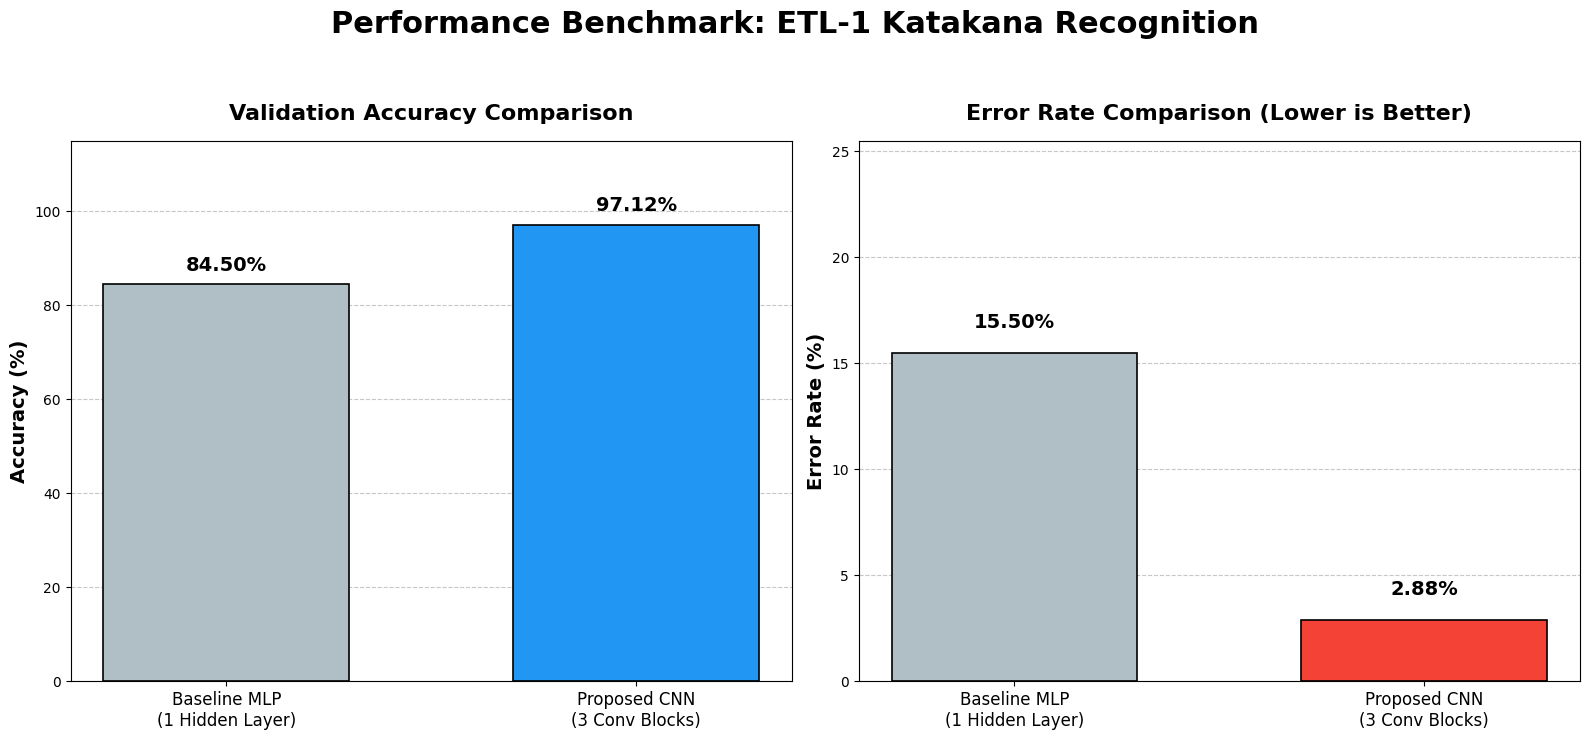

In [20]:
# Cell 6: Presentation-Ready Benchmark Visualization
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. INPUT YOUR EXACT NUMBERS HERE
# ==========================================
# Look at the output of Cell 5, and type your MLP accuracy here:
mlp_accuracy = 84.50  # <--- CHANGE THIS TO YOUR ACTUAL MLP RESULT
mlp_error = 100.0 - mlp_accuracy

# Your CNN numbers from earlier:
cnn_accuracy = 97.12
cnn_error = 2.88

# ==========================================
# 2. SETUP THE GRAPH DATA
# ==========================================
models = ['Baseline MLP\n(1 Hidden Layer)', 'Proposed CNN\n(3 Conv Blocks)']
accuracies = [mlp_accuracy, cnn_accuracy]
errors = [mlp_error, cnn_error]

# We use Gray for the baseline, Blue for CNN Success, and Red for CNN Errors
acc_colors = ['#B0BEC5', '#2196F3'] 
err_colors = ['#B0BEC5', '#F44336']

# Set up a beautiful, wide side-by-side canvas
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# ==========================================
# 3. PLOT 1: ACCURACY COMPARISON
# ==========================================
bars_acc = ax[0].bar(models, accuracies, color=acc_colors, width=0.6, edgecolor='black', linewidth=1.2)
ax[0].set_title('Validation Accuracy Comparison', fontsize=16, fontweight='bold', pad=15)
ax[0].set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax[0].set_ylim(0, 115) # Extra room on top for the text labels
ax[0].tick_params(axis='x', labelsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)
ax[0].set_axisbelow(True)

# Add exact numbers on top of the bars
for bar in bars_acc:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold', color='black')

# ==========================================
# 4. PLOT 2: ERROR RATE COMPARISON
# ==========================================
bars_err = ax[1].bar(models, errors, color=err_colors, width=0.6, edgecolor='black', linewidth=1.2)
ax[1].set_title('Error Rate Comparison (Lower is Better)', fontsize=16, fontweight='bold', pad=15)
ax[1].set_ylabel('Error Rate (%)', fontsize=14, fontweight='bold')
ax[1].set_ylim(0, max(errors) + 10) # Dynamically scale the Y-axis
ax[1].tick_params(axis='x', labelsize=12)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)
ax[1].set_axisbelow(True)

# Add exact numbers on top of the bars
for bar in bars_err:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold', color='black')

# ==========================================
# 5. RENDER
# ==========================================
plt.suptitle('Performance Benchmark: ETL-1 Katakana Recognition', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Generating predictions for the Baseline MLP...
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


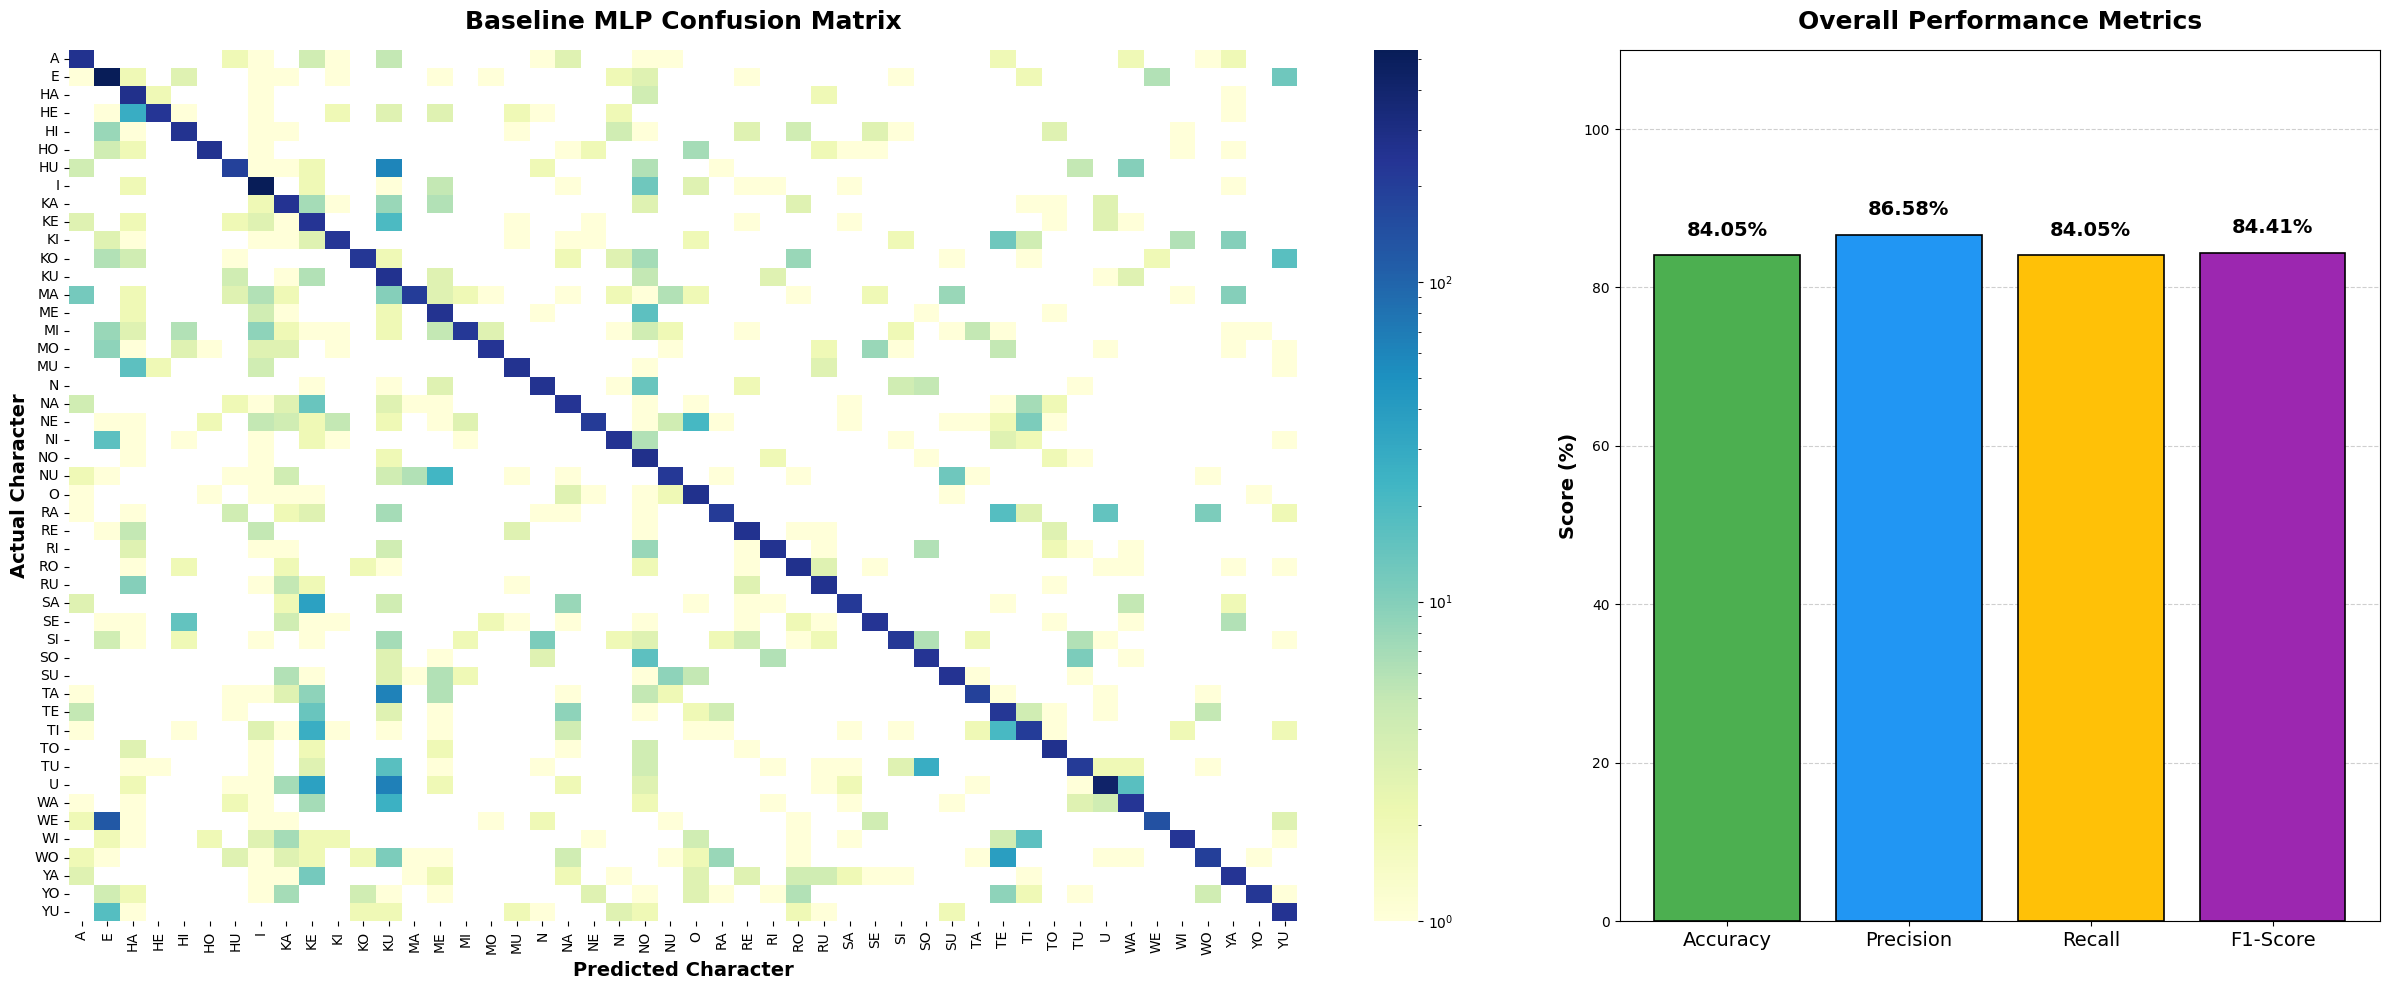

In [21]:
# Cell 7: Full Metrics Dashboard (Matrix + Bar Chart)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Generating predictions for the Baseline MLP...")
# 1. Generate Predictions
y_pred_probs = baseline_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Calculate Core Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc * 100, prec * 100, rec * 100, f1 * 100]

# 3. Setup the Dashboard Layout
fig = plt.figure(figsize=(24, 10))
# Create a grid: 2 parts for the matrix (it needs more space), 1 part for the bars
gs = fig.add_gridspec(1, 3) 
ax_matrix = fig.add_subplot(gs[0, :2]) # Spans the first two columns
ax_bars = fig.add_subplot(gs[0, 2])    # Takes the last column

# ==========================================
# PLOT 1: The Confusion Matrix (Log-Scale)
# ==========================================
cm = confusion_matrix(y_test, y_pred)

# We use the LogNorm trick again so mistakes pop out visually
sns.heatmap(cm, annot=False, cmap='YlGnBu', 
            xticklabels=classes, yticklabels=classes, 
            norm=LogNorm(), ax=ax_matrix)

ax_matrix.set_title('Baseline MLP Confusion Matrix', fontsize=18, fontweight='bold', pad=15)
ax_matrix.set_ylabel('Actual Character', fontsize=14, fontweight='bold')
ax_matrix.set_xlabel('Predicted Character', fontsize=14, fontweight='bold')
ax_matrix.tick_params(axis='x', rotation=90)
ax_matrix.tick_params(axis='y', rotation=0)

# ==========================================
# PLOT 2: The Core Metrics Bar Chart
# ==========================================
# Use a sleek color palette for the bars
colors = ['#4CAF50', '#2196F3', '#FFC107', '#9C27B0']

bars = ax_bars.bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.2)

ax_bars.set_title('Overall Performance Metrics', fontsize=18, fontweight='bold', pad=15)
ax_bars.set_ylabel('Score (%)', fontsize=14, fontweight='bold')
ax_bars.set_ylim(0, 110) # Give room for the text labels on top
ax_bars.tick_params(axis='x', labelsize=14)
ax_bars.grid(axis='y', linestyle='--', alpha=0.6)
ax_bars.set_axisbelow(True)

# Add the exact percentages on top of each bar
for bar in bars:
    height = bar.get_height()
    ax_bars.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()